# FcaDreamUHD — Inferenza FASE 2 (DreamUHD completo)

Questo notebook esegue l'inferenza con il modello **DreamUHD** (Stage 2), cioè la rete completa che combina il FE-VAE (Stage 1) con l'enhancer UHD.

| Stage | Modello | Descrizione |
|---|---|---|
| Stage 1 | `AutoencoderKL_freup2` | FE-VAE con FCA — solo ricostruzione |
| **Stage 2** | `DreamUHD` | **Rete completa — enhancement UHD** |

> **Accelerator**: GPU → T4 (Kaggle)

## 0. Verifica GPU

In [2]:
import torch
print(f"GPU disponibili: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  [{i}] {p.name}  —  {p.total_memory / 1024**3:.1f} GB VRAM")

GPU disponibili: 2
  [0] Tesla T4  —  14.6 GB VRAM
  [1] Tesla T4  —  14.6 GB VRAM


## 1. Dipendenze

In [3]:
%%bash
pip install -q basicsr facexlib lpips einops timm scikit-image pyyaml pyiqa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.

## 2. Copia il codice sorgente

In [5]:
import os, shutil

# ─── MODIFICA QUESTI PATH ─────────────────────────────────────────────────────
# Dataset con il codice sorgente FcaDreamuhd
CODE_SRC  = "/kaggle/input/datasets/paoloaltucci/fcadiosanto3/FcaDreamuhdTrain"
# Cartella con il checkpoint DreamUHD Stage 2 (net_g_*.pth)
CKPT_DIR  = "/kaggle/input/datasets/paoloaltucci/pesiii/pesi addestrati completo/models"  # ← adatta se necessario
# Dataset con le immagini di test
DATA_ROOT = "/kaggle/input/datasets/paoloaltucci/uhd-ll-dataset/UHD-LL"  # contiene testing_set/
# ─────────────────────────────────────────────────────────────────────────────

CODE_DEST = "/kaggle/working/FcaDreamuhd"

if os.path.exists(CODE_DEST):
    shutil.rmtree(CODE_DEST)
shutil.copytree(CODE_SRC, CODE_DEST)
print("✅ Codice copiato!")

✅ Codice copiato!


## 2b. Patch `DreamUHD_arch.py` — fix `AssertionError` sul caricamento VAE

Il codice originale degli autori ha:
```python
assert len(msg.missing_keys) == a
```
Questo crasha perché `msg.missing_keys` include anche i **buffer wavelet** (`wt_filter`, `iwt_filter`)
della `WTConv2d`, che **non appaiono** in `named_parameters()` (sono registrati come buffer, non parametri).  
La patch separa i missing keys in parametri trainabili e buffer fissi, e fa l'assert solo sui parametri.

In [6]:
ARCH_FILE = os.path.join(CODE_DEST, "basicsr/archs/DreamUHD_arch.py")

with open(ARCH_FILE, "r") as f:
    src = f.read()

# ── Blocco originale difettoso ────────────────────────────────────────────────
OLD_BLOCK = """            a = 0
            for name, param in self.vae.named_parameters():
                if name in msg.missing_keys:
                    param.requires_grad = True
                    a += 1
                else:
                    param.requires_grad = False
            print(f"adapter num is {a}")
            assert len(msg.missing_keys) == a"""

# ── Versione corretta che separa params da buffer ─────────────────────────────
NEW_BLOCK = """            # Separa i missing keys in: parametri (trainabili) e buffer wavelet (fissi).
            # L'assert originale crashava perché wt_filter/iwt_filter sono in
            # msg.missing_keys ma NON in named_parameters() (sono registrati come
            # buffer dalla wtconv library, non come parametri con requires_grad).
            _param_names  = {n for n, _ in self.vae.named_parameters()}
            _buffer_names = {n for n, _ in self.vae.named_buffers()}
            _missing_set  = set(msg.missing_keys)

            _missing_params  = _missing_set & _param_names
            _missing_buffers = _missing_set & _buffer_names
            _missing_other   = _missing_set - _param_names - _buffer_names

            a = 0
            for name, param in self.vae.named_parameters():
                if name in _missing_set:
                    param.requires_grad = True
                    a += 1
                else:
                    param.requires_grad = False

            print(f"adapter num (trainable missing params) : {a}")
            print(f"missing buffers (wavelet filters, ok)  : {len(_missing_buffers)}")
            if _missing_other:
                print(f"WARNING: {len(_missing_other)} missing keys non sono ne' params ne' buffers: {list(_missing_other)[:5]}")

            # Assert solo sui parametri trainabili — i buffer mancanti sono ok.
            assert len(_missing_params) == a, (
                f"Mismatch: {len(_missing_params)} missing params ma {a} trovati in named_parameters()"
            )"""

if OLD_BLOCK in src:
    src_patched = src.replace(OLD_BLOCK, NEW_BLOCK, 1)
    with open(ARCH_FILE, "w") as f:
        f.write(src_patched)
    print("✅ Patch applicata: assert difettoso sostituito con versione robusta.")
elif "_missing_params" in src:
    print("ℹ️  Patch già presente nel dataset — nessuna modifica necessaria.")
else:
    # Il pattern esatto non è stato trovato: diagnostica
    print("⚠️  Pattern OLD_BLOCK non trovato. Stampo le righe intorno all'assert per diagnostica:")
    lines = src.splitlines()
    for i, line in enumerate(lines):
        if 'assert' in line and 'missing_keys' in line:
            start = max(0, i - 10)
            end   = min(len(lines), i + 3)
            print(f"\n--- Righe {start+1}–{end+1} ---")
            for j in range(start, end):
                print(f"{j+1:4d}: {lines[j]}")
            break
    print("\nModifica manualmente OLD_BLOCK nella cella qui sopra copiando le righe esatte.")

ℹ️  Patch già presente nel dataset — nessuna modifica necessaria.


## 3. Carica la rete DreamUHD (Stage 2)

La rete DreamUHD in Stage 2 usa:
- La config `DreamUHD_LL.yml` per la definizione della rete
- Un checkpoint `net_g_*.pth` prodotto dal training Stage 2
- Il peso VAE (`vae_weight`) specificato nel config (o sovrascrivibile qui)

In [17]:
import sys
import torch
import yaml
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, CODE_DEST)
from basicsr.archs import build_network

# ─── PERCORSI DA MODIFICARE ───────────────────────────────────────────────────
# Config DreamUHD Stage 2
CONFIG_PATH  = os.path.join(CODE_DEST, "options/DreamUHD_LL.yml")

# Checkpoint DreamUHD Stage 2 — scegli il .pth più recente nel tuo CKPT_DIR
# Esempi:
#   net_g_30000.pth  ← prodotto dal kaggle_train Stage 2
#   DreamUHD_lowlight.pth  ← peso pre-addestrato degli autori originali
DREAM_WEIGHT = os.path.join(CKPT_DIR, "net_g_30000.pth")

# Peso VAE Stage 1 — usato internamente da DreamUHD al momento della costruzione
VAE_WEIGHT   = os.path.join(CODE_DEST, "weight/VAE_LL.pth")
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Carica la config
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# ── FIX KeyError: gestisce automaticamente param_key del VAE ──
try:
    vae_ckpt = torch.load(VAE_WEIGHT, map_location='cpu')
    vae_keys = list(vae_ckpt.keys())
    if "params_ema" in vae_keys:
        cfg["network_g"]["param_key"] = "params_ema"
    elif "params" in vae_keys:
        cfg["network_g"]["param_key"] = "params"
    else:
        # Se è raw state_dict, lo wrappiamo al volo per evitare il KeyError in DreamUHD_arch.py
        wrapped_vae_path = "/kaggle/working/vae_wrapped.pth"
        torch.save({"params": vae_ckpt}, wrapped_vae_path)
        VAE_WEIGHT = wrapped_vae_path
        cfg["network_g"]["param_key"] = "params"
except Exception as e:
    print(f"⚠️ Errore lettura VAE_WEIGHT: {e}")

# Sovrascrive i percorsi VAE con quelli locali Kaggle aggiornati
cfg["network_g"]["vae_weight"] = VAE_WEIGHT
cfg["network_g"]["config"]     = os.path.join(CODE_DEST, "options/VAE_LL.yml")

print("📋 Config DreamUHD (network_g):")
for k, v in cfg["network_g"].items():
    print(f"   {k}: {v}")

📋 Config DreamUHD (network_g):
   type: DreamUHD
   dim: 16
   dwt_dim: 3
   n_blocks: 8
   ffn_scale: 2.0
   upscaling_factor: 8
   param_key: params_ema
   num_heads: 3
   out_dim: 64
   vae_weight: /kaggle/working/FcaDreamuhd/weight/VAE_LL.pth
   config: /kaggle/working/FcaDreamuhd/options/VAE_LL.yml
   sample: True


In [18]:
# Costruisce la rete DreamUHD (la patch 2b deve essere stata eseguita prima)
model = build_network(cfg["network_g"]).to(device)

# Carica i pesi Stage 2
ckpt = torch.load(DREAM_WEIGHT, map_location=device)
print("🔑 Chiavi nel checkpoint:", list(ckpt.keys()))

# Gestione automatica della chiave params / params_ema
if "params_ema" in ckpt:
    state_dict = ckpt["params_ema"]
elif "params" in ckpt:
    state_dict = ckpt["params"]
else:
    state_dict = ckpt

model.load_state_dict(state_dict, strict=True)
model.eval()
print("✅ Modello DreamUHD (Stage 2) caricato!")

num_params = sum(p.numel() for p in model.parameters())
print(f"   Parametri totali: {num_params:,}")

making res of type 'FE-block' with 16 in_channels
making res of type 'FE-block' with 16 in_channels
making res of type 'FE-block' with 16 in_channels
making res of type 'FE-block' with 32 in_channels
making res of type 'FE-block' with 32 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making res of type 'FE-block' with 64 in_channels
making attention of type 'restormer' with 64 in_channels
making res of type 'FE-block' with 64 in_channels


## 4. Funzioni di utilità (tile-based per immagini UHD)

In [19]:
import math
import torch.nn.functional as F


def check_image_size(x, window_size=128):
    """Pad l'immagine in modo che sia divisibile per window_size."""
    _, _, h, w = x.size()
    mod_pad_h = (window_size - h % window_size) % window_size
    mod_pad_w = (window_size - w % window_size) % window_size
    x = F.pad(x, (0, mod_pad_w, 0, mod_pad_h), 'reflect')
    return x


@torch.no_grad()
def test_tile(net, lq, tile_size=1024, tile_pad=16):
    """Inferenza a tile per immagini UHD di grandi dimensioni.
    Adattato da: https://github.com/xinntao/Real-ESRGAN
    """
    batch, channel, height, width = lq.shape
    output = lq.new_zeros((batch, channel, height, width))
    tiles_x = math.ceil(width  / tile_size)
    tiles_y = math.ceil(height / tile_size)

    for y in range(tiles_y):
        for x in range(tiles_x):
            ofs_x = x * tile_size
            ofs_y = y * tile_size

            in_x0 = ofs_x
            in_x1 = min(ofs_x + tile_size, width)
            in_y0 = ofs_y
            in_y1 = min(ofs_y + tile_size, height)

            in_x0_pad = max(in_x0 - tile_pad, 0)
            in_x1_pad = min(in_x1 + tile_pad, width)
            in_y0_pad = max(in_y0 - tile_pad, 0)
            in_y1_pad = min(in_y1 + tile_pad, height)

            tw = in_x1 - in_x0
            th = in_y1 - in_y0

            tile = lq[:, :, in_y0_pad:in_y1_pad, in_x0_pad:in_x1_pad]
            tile_out = net(tile)
            # Gestisce output tuple (es. (out, features))
            if isinstance(tile_out, (tuple, list)):
                tile_out = tile_out[0]

            ox0_tile = in_x0 - in_x0_pad
            oy0_tile = in_y0 - in_y0_pad

            output[:, :, in_y0:in_y1, in_x0:in_x1] = \
                tile_out[:, :, oy0_tile:oy0_tile + th, ox0_tile:ox0_tile + tw]

    return output


print("✅ Funzioni di utilità definite")

✅ Funzioni di utilità definite


## 5. Test su una singola immagine UHD

🖼️  Immagine input : 1043_UHD_LL.JPG (2880x1620)
   Tensor shape   : torch.Size([1, 3, 1620, 2880])
   Tensor padded  : torch.Size([1, 3, 1664, 2944])
   Tempo inferenza: 2.08s


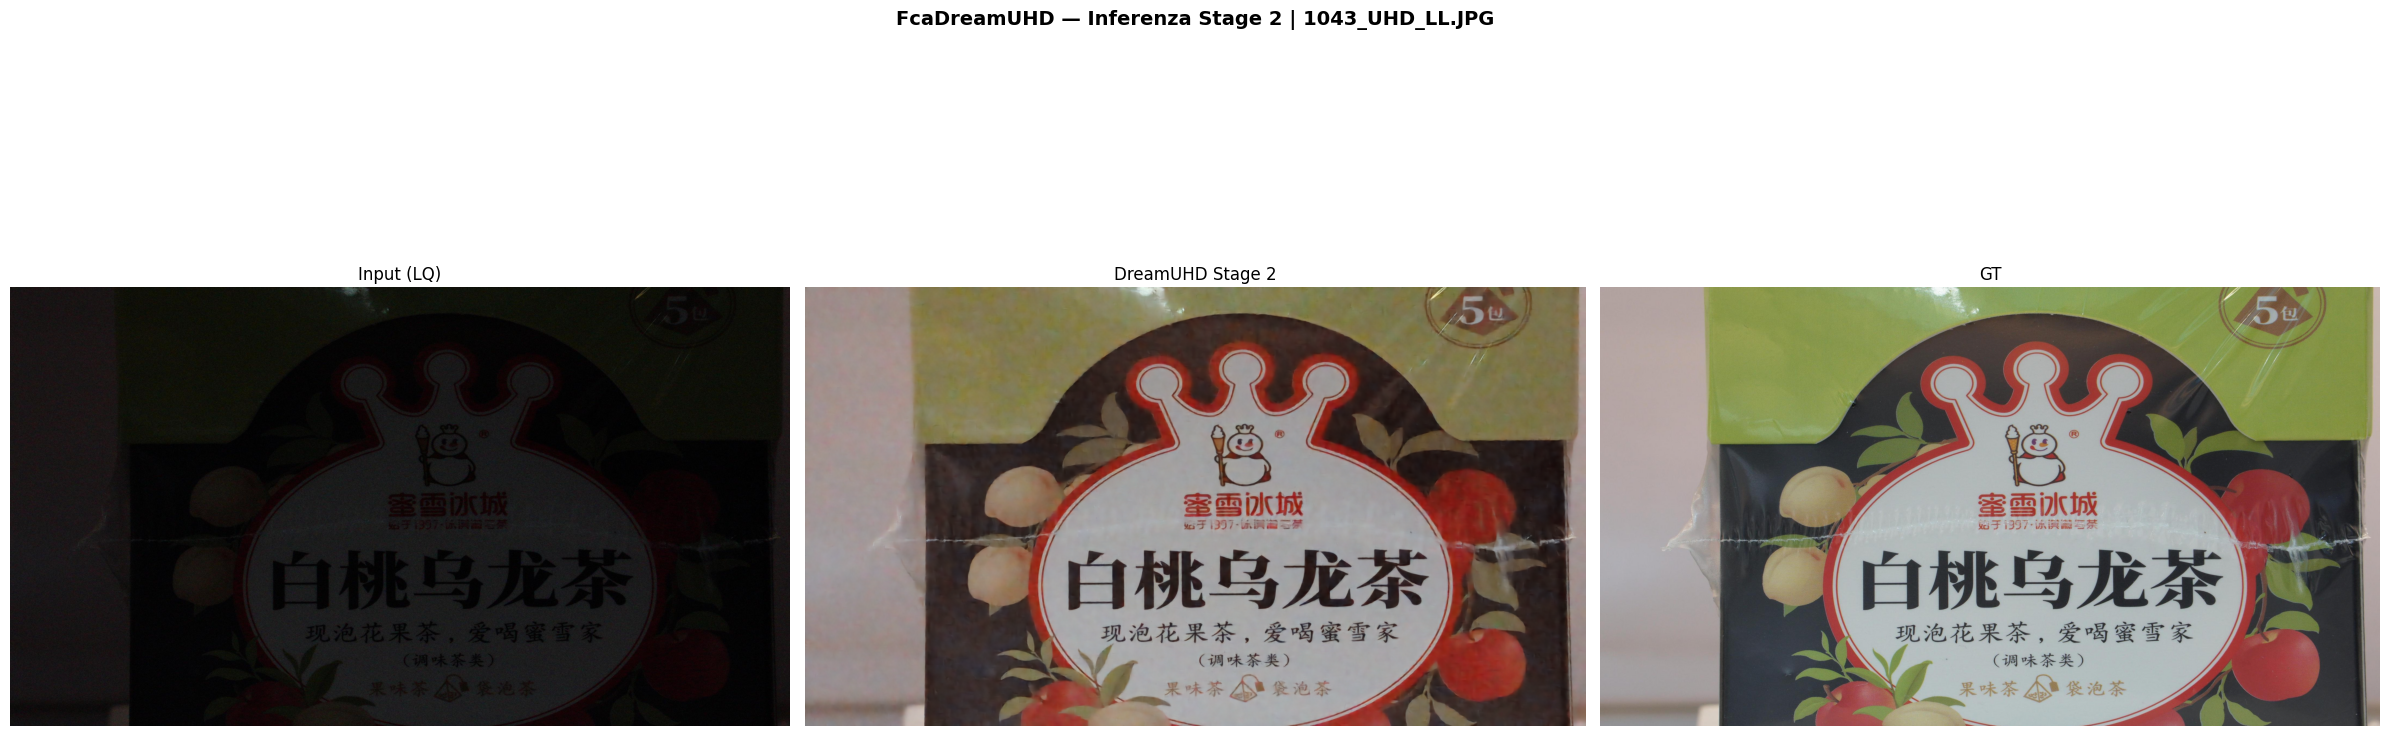

In [30]:
import time

# ─── MODIFICA: percorso della cartella di input (immagini degradate) ──────────
INPUT_DIR = os.path.join(DATA_ROOT, 'testing_set/input')
# Opzionale: cartella GT per confronto visivo
GT_DIR    = os.path.join(DATA_ROOT, 'testing_set/gt')
# Indice dell'immagine da visualizzare
IMG_IDX   = 3
# Usa inferenza a tile (consigliato per immagini 4K)
USE_TILE  = False
TILE_SIZE = 1024
# Parametri per il crop a 3K
CROP_W    = 2880
CROP_H    = 1620
# ─────────────────────────────────────────────────────────────────────────────

img_files = sorted(os.listdir(INPUT_DIR))
img_path  = os.path.join(INPUT_DIR, img_files[IMG_IDX])
img       = Image.open(img_path).convert('RGB')

# Calcolo coordinate per Center Crop a 3K
orig_w, orig_h = img.size
left = (orig_w - CROP_W) // 2
top = (orig_h - CROP_H) // 2
right = left + CROP_W
bottom = top + CROP_H
crop_box = (left, top, right, bottom)

# Esecuzione del crop sull'input
img = img.crop(crop_box)

img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)

print(f"🖼️  Immagine input : {os.path.basename(img_path)} ({img.size[0]}x{img.size[1]})")
print(f"   Tensor shape   : {img_tensor.shape}")

# Padding per compatibilità con la rete
b, c, h, w = img_tensor.shape
img_padded = check_image_size(img_tensor)
print(f"   Tensor padded  : {img_padded.shape}")

# ─── Inferenza ────────────────────────────────────────────────────────────────
t0 = time.time()
with torch.no_grad():
    if USE_TILE:
        output_tensor = test_tile(model, img_padded, tile_size=TILE_SIZE)
    else:
        out = model(img_padded)
        output_tensor = out[0] if isinstance(out, (tuple, list)) else out
t1 = time.time()
print(f"   Tempo inferenza: {t1 - t0:.2f}s")

# Ritaglia al formato originale (3K)
output_tensor = output_tensor[:, :, :h, :w]
out_img = TF.to_pil_image(output_tensor.squeeze(0).clamp(0, 1).cpu())

# ─── Visualizzazione ──────────────────────────────────────────────────────────
has_gt = os.path.exists(GT_DIR)
n_cols = 3 if has_gt else 2
fig, axs = plt.subplots(1, n_cols, figsize=(8 * n_cols, 10))

axs[0].imshow(img);     axs[0].set_title("Input (LQ)");        axs[0].axis('off')
axs[1].imshow(out_img); axs[1].set_title("DreamUHD Stage 2"); axs[1].axis('off')

if has_gt:
    gt_files = sorted(os.listdir(GT_DIR))
    gt_path  = os.path.join(GT_DIR, gt_files[IMG_IDX])
    gt_img   = Image.open(gt_path).convert('RGB')
    # Ritaglio allineato per la Ground Truth
    gt_img   = gt_img.crop(crop_box)
    axs[2].imshow(gt_img); axs[2].set_title("GT"); axs[2].axis('off')

plt.suptitle(f"FcaDreamUHD — Inferenza Stage 2 | {os.path.basename(img_path)}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Metriche PSNR / SSIM su un'immagine

In [31]:
import numpy as np
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
import cv2

def pil_to_np(img):
    return np.array(img)

def psnr_gray(imgA, imgB):
    gA = cv2.cvtColor(pil_to_np(imgA), cv2.COLOR_RGB2GRAY)
    gB = cv2.cvtColor(pil_to_np(imgB), cv2.COLOR_RGB2GRAY)
    return psnr_fn(gA, gB)

def ssim_gray(imgA, imgB):
    gA = cv2.cvtColor(pil_to_np(imgA), cv2.COLOR_RGB2GRAY)
    gB = cv2.cvtColor(pil_to_np(imgB), cv2.COLOR_RGB2GRAY)
    score, _ = ssim_fn(gA, gB, full=True)
    return score

if has_gt:
    psnr_val = psnr_gray(out_img, gt_img)
    ssim_val = ssim_gray(out_img, gt_img)
    print(f"📊 PSNR (Y): {psnr_val:.2f} dB")
    print(f"   SSIM (Y): {ssim_val:.4f}")
else:
    print("⚠️ Nessuna cartella GT trovata — metriche non calcolate.")

📊 PSNR (Y): 22.64 dB
   SSIM (Y): 0.8572


## 7. Inferenza batch su tutto il test set + salvataggio output

In [33]:
from tqdm.notebook import tqdm

# ─── MODIFICA ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working/dreamuhd_results"
COMPUTE_METRICS = True   # richiede GT_DIR valida
# Parametri per il crop a 3K
CROP_W = 2880
CROP_H = 1620
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

img_files_sorted = sorted(os.listdir(INPUT_DIR))
gt_files_sorted  = sorted(os.listdir(GT_DIR)) if (has_gt and COMPUTE_METRICS) else []

psnr_list, ssim_list = [], []

pbar = tqdm(img_files_sorted, desc="DreamUHD inference", unit="img")
for i, fname in enumerate(pbar):
    img_path  = os.path.join(INPUT_DIR, fname)
    img       = Image.open(img_path).convert('RGB')
    
    # Calcolo e applicazione del Center Crop a 3K
    orig_w, orig_h = img.size
    left = (orig_w - CROP_W) // 2
    top = (orig_h - CROP_H) // 2
    right = left + CROP_W
    bottom = top + CROP_H
    crop_box = (left, top, right, bottom)
    
    img = img.crop(crop_box)

    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)

    b, c, h, w = img_tensor.shape
    img_padded = check_image_size(img_tensor)

    t0 = time.time()
    with torch.no_grad():
        # Inferenza standard (non tiled)
        out = model(img_padded)
        out_t = out[0] if isinstance(out, (tuple, list)) else out
    t1 = time.time()

    out_t   = out_t[:, :, :h, :w]
    out_img = TF.to_pil_image(out_t.squeeze(0).clamp(0, 1).cpu())

    # Salva
    save_path = os.path.join(OUTPUT_DIR, fname)
    out_img.save(save_path)

    # Metriche
    if gt_files_sorted and i < len(gt_files_sorted):
        gt_img = Image.open(os.path.join(GT_DIR, gt_files_sorted[i])).convert('RGB')
        
        # Applica lo stesso ritaglio alla Ground Truth
        gt_img = gt_img.crop(crop_box)
        
        psnr_v = psnr_gray(out_img, gt_img)
        ssim_v = ssim_gray(out_img, gt_img)
        psnr_list.append(psnr_v)
        ssim_list.append(ssim_v)
        pbar.set_postfix(psnr=f"{psnr_v:.2f}", ssim=f"{ssim_v:.4f}", t=f"{t1-t0:.1f}s")
    else:
        pbar.set_postfix(t=f"{t1-t0:.1f}s")

print(f"\n✅ Risultati salvati in: {OUTPUT_DIR}")
if psnr_list:
    print(f"📊 PSNR medio (Y): {sum(psnr_list)/len(psnr_list):.2f} dB")
    print(f"   SSIM medio (Y): {sum(ssim_list)/len(ssim_list):.4f}")

DreamUHD inference:   0%|          | 0/150 [00:00<?, ?img/s]


✅ Risultati salvati in: /kaggle/working/dreamuhd_results
📊 PSNR medio (Y): 24.65 dB
   SSIM medio (Y): 0.8929


## 8. Confronto visivo: griglia di campioni dal test set

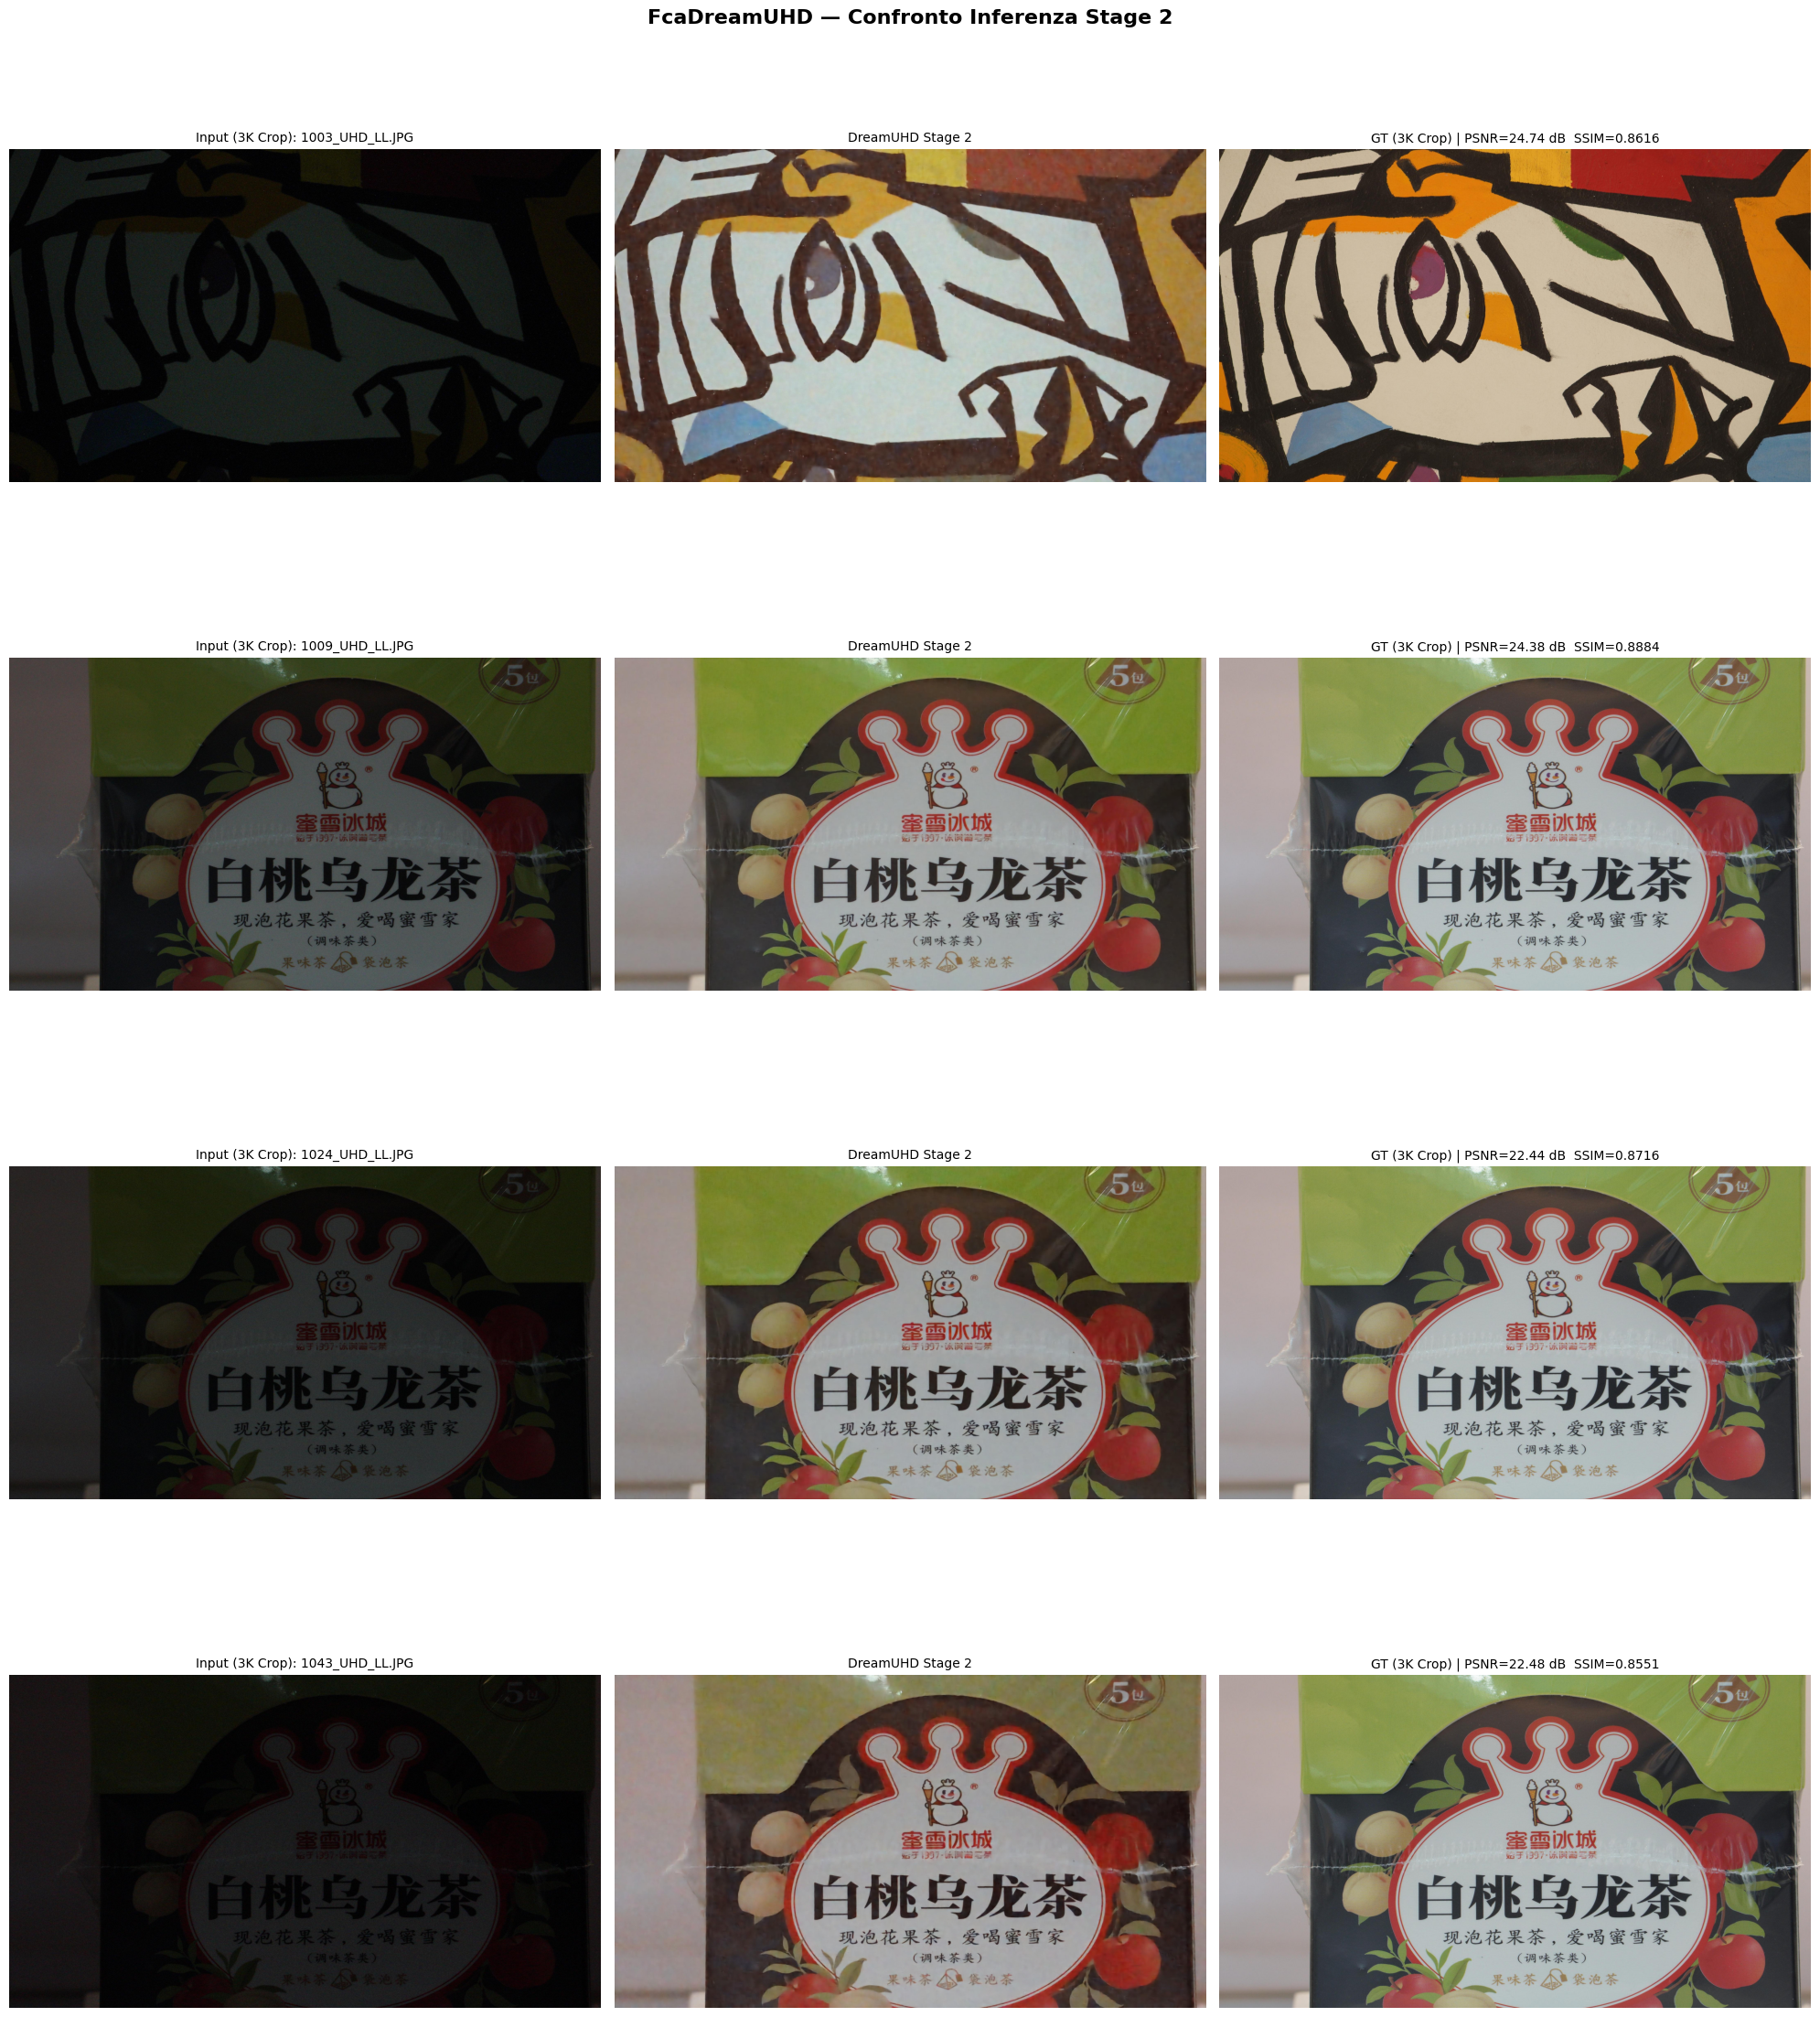

In [35]:
# Mostra N campioni a confronto (Input | Output | GT)
N_SAMPLES = 4
indices   = list(range(min(N_SAMPLES, len(img_files_sorted))))

# Parametri per il crop a 3K
CROP_W = 2880
CROP_H = 1620

fig, axes = plt.subplots(len(indices), 3 if has_gt else 2,
                         figsize=(20, 6 * len(indices)))
if len(indices) == 1:
    axes = [axes]

for row, idx in enumerate(indices):
    fname = img_files_sorted[idx]

    inp = Image.open(os.path.join(INPUT_DIR, fname)).convert('RGB')
    out = Image.open(os.path.join(OUTPUT_DIR, fname)).convert('RGB')

    # Calcolo coordinate e applicazione del Center Crop sull'input
    orig_w, orig_h = inp.size
    left = (orig_w - CROP_W) // 2
    top = (orig_h - CROP_H) // 2
    right = left + CROP_W
    bottom = top + CROP_H
    crop_box = (left, top, right, bottom)

    inp = inp.crop(crop_box)

    axes[row][0].imshow(inp)
    axes[row][0].set_title(f"Input (3K Crop): {fname}", fontsize=10)
    axes[row][0].axis('off')

    axes[row][1].imshow(out)
    axes[row][1].set_title("DreamUHD Stage 2", fontsize=10)
    axes[row][1].axis('off')

    if has_gt and idx < len(gt_files_sorted):
        gt = Image.open(os.path.join(GT_DIR, gt_files_sorted[idx])).convert('RGB')
        
        # Applica l'esatto crop box alla GT per pareggiare la risoluzione con out
        gt = gt.crop(crop_box)
        
        pv = psnr_gray(out, gt)
        sv = ssim_gray(out, gt)
        axes[row][2].imshow(gt)
        axes[row][2].set_title(f"GT (3K Crop) | PSNR={pv:.2f} dB  SSIM={sv:.4f}", fontsize=10)
        axes[row][2].axis('off')

plt.suptitle("FcaDreamUHD — Confronto Inferenza Stage 2", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()